# Notebook 02 — Landmarks e Alinhamento

## Objetivo de aprendizado

Aprender a **segunda etapa** do pipeline: depois que achamos o rosto, **onde estão os olhos, nariz, boca?** E **por que rotacionar o rosto** antes de gerar o embedding melhora drasticamente o reconhecimento.

## Resumo da intuição

O modelo de embedding (próximo notebook) foi treinado com rostos **alinhados** — olhos na horizontal, nariz no centro. Se você der pra ele um rosto inclinado 30° pro lado, o embedding fica **diferente** do mesmo rosto reto. Resultado: a distância entre "você inclinado" e "você reto" pode ficar **maior** que a distância entre você e um estranho.

Alinhamento elimina essa variação inútil. É **pré-processamento clássico**, mas crítico.

## Conceitos novos

- **Landmarks faciais**: pontos de referência no rosto. O dlib detecta **68 pontos** (modelo Kazemi & Sullivan, 2014): contorno do queixo, sobrancelhas, nariz, olhos, boca.
- **Alinhamento (face alignment)**: rotacionar (e às vezes escalar) o recorte do rosto para que os olhos fiquem na mesma horizontal.
- **Transformação afim**: o tipo de transformação geométrica (rotação + translação + escala) que usamos pra alinhar.

## 1. Setup

In [1]:
from pathlib import Path

import cv2
import face_recognition
import matplotlib.pyplot as plt
import numpy as np

DATASET_DIR = Path('../dataset/diogo')
fotos = sorted(DATASET_DIR.glob('*.jp*g')) + sorted(DATASET_DIR.glob('*.png'))
print(f'{len(fotos)} fotos disponíveis.')

/home/diogo/Coding/AILAB-FACIAL/.venv/lib/python3.13/site-packages/face_recognition_models/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


8 fotos disponíveis.


## 2. Extrair os 68 landmarks

O `face_recognition.face_landmarks()` devolve um dicionário com grupos de pontos: `chin`, `left_eyebrow`, `right_eyebrow`, `nose_bridge`, `nose_tip`, `left_eye`, `right_eye`, `top_lip`, `bottom_lip`.

> Cada grupo é uma lista de coordenadas `(x, y)`. Somados, dão os 68 pontos do modelo clássico do dlib.

In [2]:
img = face_recognition.load_image_file(fotos[0])
landmarks_list = face_recognition.face_landmarks(img)
print(f'Pessoas detectadas: {len(landmarks_list)}')
if landmarks_list:
    lm = landmarks_list[0]
    for grupo, pontos in lm.items():
        print(f'  {grupo:15s}: {len(pontos)} pontos  ex: {pontos[0]}')

Pessoas detectadas: 1
  chin           : 17 pontos  ex: (230, 757)
  left_eyebrow   : 5 pontos  ex: (275, 689)
  right_eyebrow  : 5 pontos  ex: (509, 632)
  nose_bridge    : 4 pontos  ex: (476, 694)
  nose_tip       : 5 pontos  ex: (431, 853)
  left_eye       : 6 pontos  ex: (330, 733)
  right_eye      : 6 pontos  ex: (544, 714)
  top_lip        : 12 pontos  ex: (395, 958)
  bottom_lip     : 12 pontos  ex: (581, 945)


## 3. Visualizar os landmarks

Desenha os 68 pontos sobre cada foto.

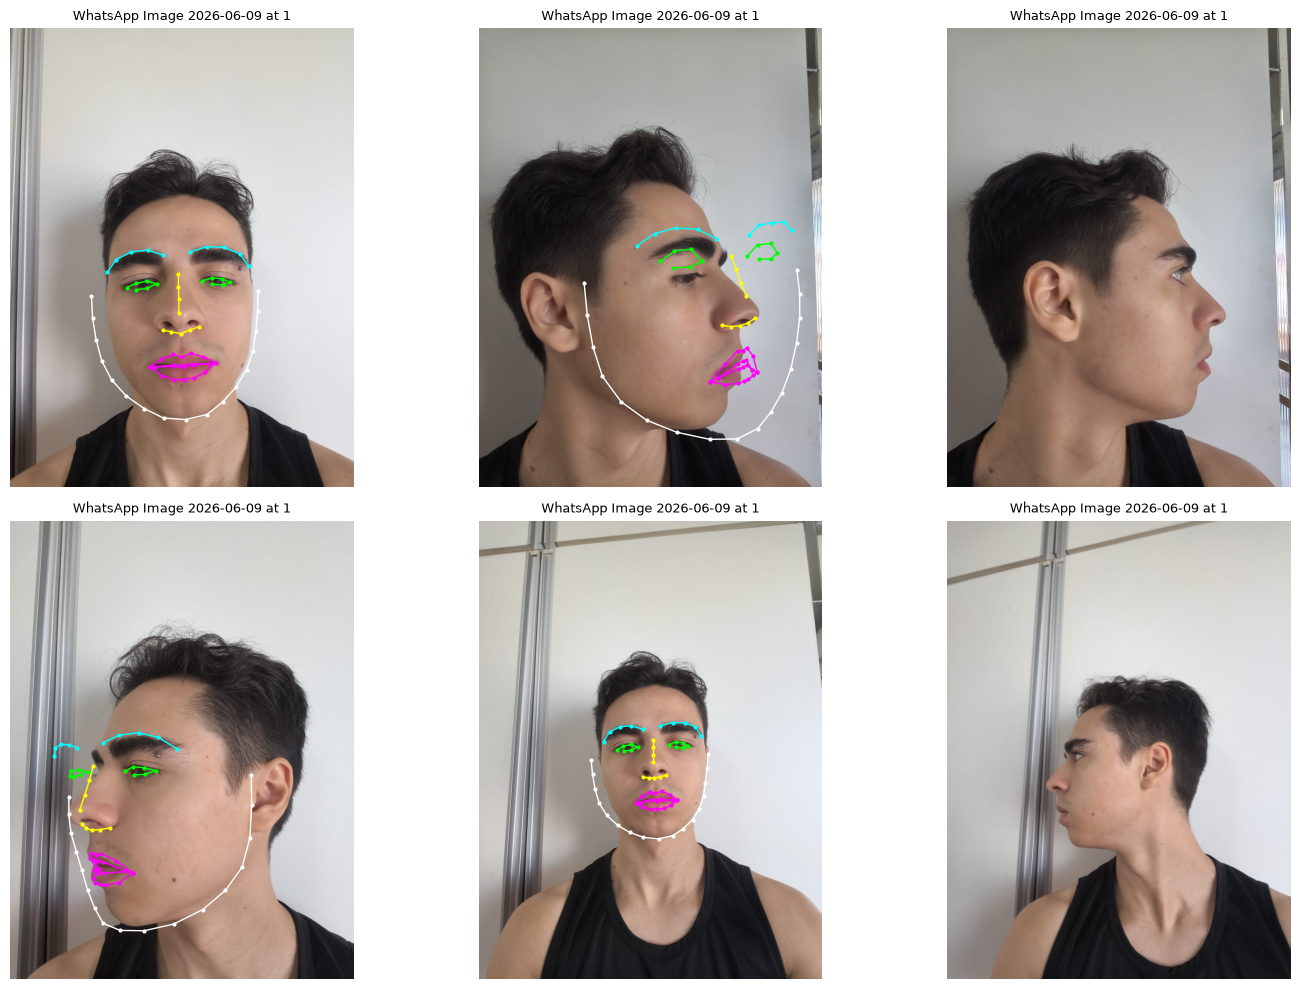

In [3]:
CORES = {
    'chin': 'white', 'left_eyebrow': 'cyan', 'right_eyebrow': 'cyan',
    'nose_bridge': 'yellow', 'nose_tip': 'yellow',
    'left_eye': 'lime', 'right_eye': 'lime',
    'top_lip': 'magenta', 'bottom_lip': 'magenta',
}

def plot_landmarks(fotos, max_n=6):
    fotos = fotos[:max_n]
    cols = 3
    rows = (len(fotos) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
    axes = np.array(axes).reshape(-1)
    for ax, f in zip(axes, fotos):
        img = face_recognition.load_image_file(f)
        lms = face_recognition.face_landmarks(img)
        ax.imshow(img)
        ax.set_title(f.name[:30], fontsize=9)
        ax.axis('off')
        for lm in lms:
            for grupo, pontos in lm.items():
                xs = [p[0] for p in pontos]
                ys = [p[1] for p in pontos]
                ax.plot(xs, ys, 'o-', color=CORES[grupo], markersize=2, linewidth=1)
    for ax in axes[len(fotos):]:
        ax.axis('off')
    plt.tight_layout(); plt.show()

plot_landmarks(fotos)

### 🔎 Observe

Os pontos seguem o contorno real — sobrancelha, contorno do olho, ponta do nariz, lábios. Esses pontos são base pra muita coisa: alinhamento (agora), detecção de piscadas (anti-spoofing), expressões faciais.

## 4. Alinhamento — a parte que importa pro reconhecimento

**Receita clássica de alinhamento por olhos:**

1. Calcular o **centro** do olho esquerdo e do olho direito (média dos 6 pontos de cada um).
2. Calcular o **ângulo** entre eles: `atan2(Δy, Δx)`.
3. Rotacionar a imagem inteira por **-ângulo** em torno do ponto médio dos olhos → olhos ficam horizontais.
4. (Opcional) Recortar e redimensionar pra um tamanho canônico (ex.: 200×200).

Ângulo medido: -3.2°  (positivo = cabeça inclinada pro lado direito do observador)


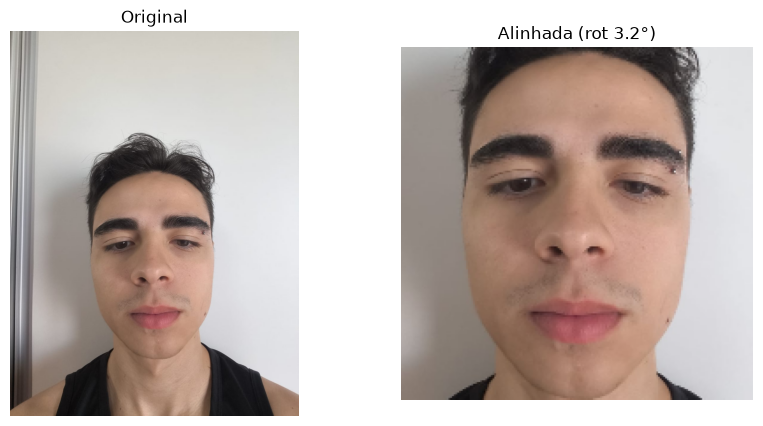

In [4]:
def alinhar_por_olhos(img, landmarks, tamanho_saida=200):
    """Recebe imagem RGB e dict de landmarks; devolve (recorte alinhado, ângulo)."""
    olho_esq = np.mean(landmarks['left_eye'], axis=0)
    olho_dir = np.mean(landmarks['right_eye'], axis=0)

    dy = olho_dir[1] - olho_esq[1]
    dx = olho_dir[0] - olho_esq[0]
    angulo = float(np.degrees(np.arctan2(dy, dx)))

    centro = ((olho_esq[0] + olho_dir[0]) / 2.0,
              (olho_esq[1] + olho_dir[1]) / 2.0)

    M = cv2.getRotationMatrix2D(centro, angulo, scale=1.0)
    h, w = img.shape[:2]
    rotacionada = cv2.warpAffine(img, M, (w, h))

    dist_olhos = float(np.hypot(dx, dy))
    lado = int(dist_olhos * 3.0)
    cx, cy = int(centro[0]), int(centro[1])
    x0 = max(0, cx - lado // 2)
    y0 = max(0, cy - int(lado * 0.4))
    x1 = min(w, x0 + lado)
    y1 = min(h, y0 + lado)
    recorte = rotacionada[y0:y1, x0:x1]
    if recorte.size == 0:
        return None, angulo
    return cv2.resize(recorte, (tamanho_saida, tamanho_saida)), angulo

img = face_recognition.load_image_file(fotos[0])
lms = face_recognition.face_landmarks(img)
alinhada, ang = alinhar_por_olhos(img, lms[0])
print(f'Ângulo medido: {ang:.1f}°  (positivo = cabeça inclinada pro lado direito do observador)')

fig, (a, b) = plt.subplots(1, 2, figsize=(10, 5))
a.imshow(img); a.set_title('Original'); a.axis('off')
b.imshow(alinhada); b.set_title(f'Alinhada (rot {-ang:.1f}°)'); b.axis('off')
plt.show()

## 5. Alinhar todas as fotos e ver o batch

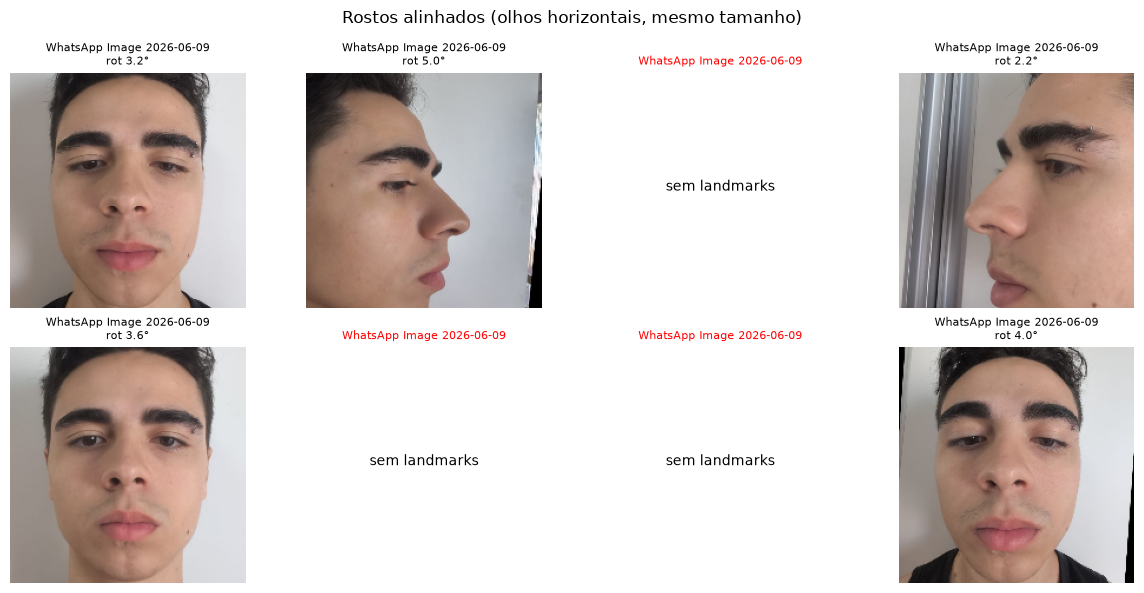

In [5]:
alinhadas = []
for f in fotos:
    img = face_recognition.load_image_file(f)
    lms = face_recognition.face_landmarks(img)
    if not lms:
        alinhadas.append((f, None, None)); continue
    rec, ang = alinhar_por_olhos(img, lms[0])
    alinhadas.append((f, rec, ang))

cols = 4
rows = (len(alinhadas) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
axes = np.array(axes).reshape(-1)
for ax, (f, rec, ang) in zip(axes, alinhadas):
    if rec is None:
        ax.text(0.5, 0.5, 'sem landmarks', ha='center')
        ax.set_title(f.name[:25], color='red', fontsize=8)
    else:
        ax.imshow(rec)
        ax.set_title(f'{f.name[:25]}\nrot {-ang:.1f}°', fontsize=8)
    ax.axis('off')
for ax in axes[len(alinhadas):]:
    ax.axis('off')
plt.suptitle('Rostos alinhados (olhos horizontais, mesmo tamanho)')
plt.tight_layout(); plt.show()

### 🔎 Observe

Todos os rostos agora estão:
- Mesma escala (distância entre olhos padronizada).
- Olhos na mesma altura.
- Recortados sem o fundo distraindo.

**Esse é exatamente o input que o modelo de embedding espera.**

## 6. Detalhe importante: o face_recognition já alinha internamente?

**Sim**, parcialmente. Quando você chama `face_recognition.face_encodings()`, ele aplica um alinhamento interno usando 5 landmarks (versão simplificada). Por isso o pipeline "funciona" mesmo sem você alinhar manualmente.

**Então por que aprendemos isso?**

1. **Saber o que está acontecendo por baixo.** Quando algo der errado na precisão, você vai suspeitar de pose/alinhamento e investigar.
2. **No PWA com face-api.js**, o alinhamento é configurável. Se mudarmos pra outro modelo no futuro (ArcFace via ONNX), talvez precisemos alinhar manualmente.
3. **Anti-spoofing futuro**: a posição dos landmarks ao longo do tempo (piscada, virar a cabeça) é o que diferencia rosto vivo de foto impressa.

## 7. Para você anotar em `notebooks/duvidas.md`

1. Qual foto sua tinha o maior ângulo de inclinação? (olhe a coluna `rot Xº` no grid acima)
2. Depois do alinhamento, suas fotos ficam visivelmente "iguais" entre si? Por quê?
3. O que aconteceria se você tirasse o passo de alinhamento e desse rostos inclinados pro embedding?

## 8. Próximo notebook

`03_embeddings.ipynb` — Como o rosto vira um **vetor de 128 dimensões**, e por que distâncias entre esses vetores **separam pessoas**. Vamos visualizar isso com PCA em 2D.
